---
title: "deepSSF Package Walkthrough"
author:
  - name: Scott Forrest
    url: https://swforrest.github.io/
    orcid: 0000-0001-9529-0108
    affiliation: Queensland University of Technology, CSIRO
    email: "scottwforrest@gmail.com"
date: today
format:
    html:
        toc: true
        number_sections: true
        code-fold: show
        code-tools: true
        code-overflow: scroll
        # embed-resources: true
        css: ../styles.css
bibliography: references.bib
abstract: |
  Here we show an example of how to use the functions in the deepSSF package, showing data loading, model training and testing and generating simulations.

  To install and use the package, visit the GitHub repository here: [https://github.com/swforrest/deepSSF_package](https://github.com/swforrest/deepSSF_package), which has instructions in the README. This script will not download with the package, but it can be accessed from the deepSSF_package repo, under the 'examples' folder (as a Jupyter notebook or a html file).

  We use data that comes with the package in the **datasets** folder, which is the GPS tracking data of a single water buffalo (~10,000 locations), and two spatial layers, NDVI (the average from 2018-2019, which covers the temporal extent of the data), and slope.
---

In [ ]:
import math
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio
import torch
from IPython.display import HTML, display  # For plotting GIFs

# Use this to load the functions used in this notebook
# You can also 'import deepssf' and call functions as deepssf.function_name
import deepssf
from deepssf import (
    ConvJointModel,
    EarlyStopping,
    ModelParams,
    create_gif,
    filter_steps_by_window,
    fit,
    get_device,
    load_environmental_layers,
    make_dataloaders,
    make_optimisers,
    negativeLogLikeLoss,
    prepare_movement_df,
    simulate_trajectory,
    validate_next_step_probs,
)

print(f"deepssf {deepssf.__version__}")
print(f"torch {torch.__version__}")

# Setup the script

## Set random seed and the device for training the model

If you have a GPU, this is where it will be specified (automatically).

In [ ]:
# Reproducibility — fix random seeds so results are the same on every run.
torch.manual_seed(42)
np.random.seed(42)

# DEVICE is capitalised — module-level constant (set once, never reassigned).
# get_device() returns 'cuda' if a GPU is available, 'mps' on Apple Silicon,
# or 'cpu' otherwise.  All tensors and the model are moved to this device.
DEVICE = get_device()
print(f"Device: {DEVICE}")

## Set script paths
If you have cloned/forked/downloaded the GitHub repo (https://github.com/swforrest/deepSSF_package) you shouldn't need to change these, but for your own analyses you will want to set these to point to where your data is and where you want outputs saved.

*All-caps names below are module-level constants — set once here and referenced throughout the notebook without being reassigned.  Python has no built-in constant keyword, so capitalisation is the community convention (PEP 8) to signal "do not change this value".*

In [ ]:
DATA_DIR = Path("../src/deepssf/datasets/data")  # location of the bundled sample data
CSV_PATH = DATA_DIR / "buffalo_djelk_id2005.csv"  # GPS tracking data, individual 2005
LAYER_PATHS = {
    "ndvi":  str(DATA_DIR / "ndvi_2005.tif"),   # Normalised Difference Vegetation Index
    "slope": str(DATA_DIR / "slope_2005.tif"),  # terrain slope derived from a DEM
}
OUTPUT_DIR   = Path("outputs")                   # figures and model checkpoints go here
SNAPSHOT_DIR = OUTPUT_DIR / "training_snapshots"  # per-batch prediction-map snapshots
OUTPUT_DIR.mkdir(exist_ok=True)

# Import data
The csv file is imported with a timestamp and an x and y coordinate. In our case the data was already in a projected format that is specific to Australia (EPSG:3112), which is the same crs as the raster data which will be imported.

In [4]:
raw_df = pd.read_csv(CSV_PATH)
print(f"Raw GPS fixes : {len(raw_df):,}")
print(f"Individuals   : {raw_df['id'].nunique()}")

# Sort by the individual ID and timestamp to ensure correct temporal order
raw_df = raw_df.sort_values(by=["id", "time"]).reset_index(drop=True)

# # Convert the 'time' column to the correct timezone (here Australia/Darwin) 
raw_df["time"] = (
        pd.to_datetime(raw_df["time"], utc=True)
        .dt.tz_convert("Australia/Darwin")
    )

raw_df.head()

Raw GPS fixes : 10,297
Individuals   : 1


,id,time,x,y
0,2005,2018-07-25 09:34:02+09:30,41941.331695,-1.435875e+06
1,2005,2018-07-25 10:34:23+09:30,41969.310875,-1.435671e+06
2,2005,2018-07-25 11:34:39+09:30,41921.521939,-1.435654e+06
3,2005,2018-07-25 12:34:17+09:30,41779.439594,-1.435601e+06
4,2005,2018-07-25 13:34:39+09:30,41841.203272,-1.435635e+06


## `load_environmental_layers()`

Reads each GeoTIFF listed in LAYER_PATHS, min–max

- Scales every band to [0, 1], and returns:
    * `env_layers`       — dict mapping layer name → 2-D NumPy array (H × W)
    * `raster_transform` — Affine object that converts pixel (row, col) indices to the projected coordinates (easting, northing) of the raster(s), which should be in the same CRS as the GPS data.  This transform is used whenever we need to translate between pixel space and real-world coordinates.


In [5]:
env_layers, raster_transform = load_environmental_layers(LAYER_PATHS)
print("Layers loaded:", list(env_layers.keys()))
for name, arr in env_layers.items():
    print(f"  {name}: shape={arr.shape}, min={arr.min():.3f}, max={arr.max():.3f}")

Layer 'ndvi': min=-0.06614641100168228, max=0.731696367263794 → scaled to [0, 1]
Layer 'slope': min=0.00013558653881773353, max=12.298083305358887 → scaled to [0, 1]
Layers loaded: ['ndvi', 'slope']
  ndvi: shape=(758, 1175), min=0.000, max=1.090
  slope: shape=(758, 1175), min=0.000, max=1.000


###  Plot each spatial covariate with the observed GPS locations overlaid.
This confirms the raster extent covers the animal's home range and gives a visual sense of the landscape the model will learn from.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

layer_plot = [
    ("ndvi",  "NDVI (scaled 0–1)",  "YlGn"),
    ("slope", "Slope (scaled 0–1)", "viridis"),
]

for ax, (name, label, cmap) in zip(axes, layer_plot, strict=False):
    rasterio.plot.show(env_layers[name], transform=raster_transform, ax=ax, cmap=cmap)
    ax.plot(
        raw_df["x"], raw_df["y"],
        "r-o", alpha=0.5, markersize=1, linewidth=0.8, label="GPS trajectory",
    )
    ax.set_xlabel("Easting (m, projected)")
    ax.set_ylabel("Northing (m, projected)")
    ax.set_title(label)
    ax.legend(loc="upper right", markerscale=6)

plt.suptitle("Spatial covariates with observed GPS locations", y=1.01)
plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / "spatial_covariates.png"), dpi=100)
plt.show()

## `prepare_movement_df()`
Converts a fixes dataframe (one row per GPS location) into a *step* dataframe (one row per movement between consecutive fixes).

- For each step it computes:
    * `dx`, `dy`         — displacement in projected CRS units (metres)
    * `bearing`          — direction of travel (radians; 0 = north, clockwise positive)
    * `bearing_tm1`      — bearing of the *previous* step, used as a model input so the network can capture directional persistence by estimating a turning angle
    * `dt_hour`          — time elapsed between consecutive fixes (hours)
    * `hour_t1`, `yday_t1` — decimal hour-of-day and day-of-year at the step start location
    * `*_sin1` / `*_cos1`  — sine/cosine encodings of hour and yday (see SCALAR_COLS below)

The trailing underscore on column names (x1_, y1_, t1_, etc.) flags them as "start of step" variables; x2_, y2_, t2_ are the corresponding "end of step" values, following the convention of the `amt` package [@Signer2019-fi]. The last fix for each individual is dropped because no forward step can be formed.

In [ ]:
step_df = prepare_movement_df(raw_df)
n_dropped = len(raw_df) - len(step_df)
print(f"Movement steps : {len(step_df):,}  ({n_dropped} dropped — last per individual)")
step_df.head()

## `SCALAR_COLS`
These are non-spatial inputs. For processing with convolutional layers, they are converted into spatial windows (rasters/arrays), and stacked with the truly spatial covariates.

The model receives a fixed-size spatial window centred on each step's start location.  To let the network express time-varying habitat preferences (e.g. different nocturnal vs diurnal use), scalar covariates are tiled into additional channels of the same H × W size, so every pixel "knows" the current time context when habitat suitability is estimated.

- `hour_t1_sin1` / `hour_t1_cos1`
    * Sine and cosine of (2π × hour / 24), encoding time-of-day as a *circular* variable.  The circular encoding means 23:00 and 01:00 are treated as adjacent — a plain hour value would have an artificial discontinuity at midnight.

- `yday_t1_sin1` / `yday_t1_cos1`
    * Same circular encoding for day-of-year (1–365), capturing seasonal variation in habitat use (e.g. dry-season vs wet-season movements).

- `dt_hour`
    * Elapsed time between consecutive fixes (hours).  Because GPS collars do not always fix at a perfectly regular rate, including dt_hour lets the movement kernel rescale expected displacement proportionally to the actual time interval rather than assuming a fixed fix rate. Note: dt_hour must be supplied at *simulation* time as well, so that `simulate_trajectory()` produces inputs consistent with training.

In [8]:
SCALAR_COLS = ["hour_t1_sin1",
               "hour_t1_cos1", 
               "yday_t1_sin1", 
               "yday_t1_cos1", 
               "dt_hour"]


## `WINDOW_SIZE`
The size of the local availability window in cells/pixels; 101 pixels × 25 m = 2525 m from the centre location to the edge

In [9]:
WINDOW_SIZE = 101  

## `PIXEL_SIZE`
Raster resolution in metres — must match the loaded GeoTIFFs

In [10]:
PIXEL_SIZE  = 25    

## `BATCH_SIZE`
Number of training samples (movement steps) per training mini-batch

In [11]:
BATCH_SIZE  = 32    

## `OUTPUT_CHANNELS`
Number of convolutional filters (and therefore feature maps) for each convolution layer. More convolutional filters can provide more flexible functions, but will increase the number of parameters and slow down training times.

In [12]:
OUTPUT_CHANNELS = 4

### Pre-calculate the flattened CNN output size 
This value will be the input to the fully-connected layers in the movement subnetwork, and is calculated here so that ModelParams can be set without hard-coding it.  

- The formula mirrors the layers inside ConvJointModel: 
    * conv (padding=1) keeps the spatial dimension unchanged at each layer
    * maxpool k=2 - the number of max pooling layers (set in the model code and isn't currently editable in this script)
    * s=2 halves the spatial dimension (floor division) at each layer

In [13]:
dim = WINDOW_SIZE
for _ in range(3):
    dim = math.floor((dim + 2 * 1 - 3) / 1 + 1)  # conv (pad=1 preserves dim)
    dim = math.floor((dim - 2) / 2 + 1)           # maxpool k=2, s=2
DENSE_DIM = OUTPUT_CHANNELS * dim * dim
print(f"After 3× conv+maxpool: dim={dim}  →  dense_dim_in_all={DENSE_DIM}")

After 3× conv+maxpool: dim=12  →  dense_dim_in_all=576


## `filter_steps_by_window()` 
Removes steps whose straight-line displacement exceeds half the spatial window (WINDOW_SIZE × PIXEL_SIZE / 2 metres). Such steps would place the true next location outside the predicted probability map, causing an index error in the loss function.

In [ ]:
step_df = filter_steps_by_window(
    step_df, window_size=WINDOW_SIZE, pixel_size=PIXEL_SIZE
)
print(f"Steps after window filter: {len(step_df):,}")

## `make_dataloaders()` 
Splits step_df chronologically into train / val / test subsets (here 80 / 10 / 10 %) and returns a PyTorch DataLoader for each.

- Each DataLoader yields tuples of:
    * `x1`  
        — spatial window tensor  (batch × n_spatial_channels × H × W)
        - One channel per entry in LAYER_PATHS, cropped around each step's start pixel.
    * `x2`  
        — scalar covariate tensor (batch × len(SCALAR_COLS))
        - Raw scalar values; broadcast into spatial maps *inside* the model.
    * `x3`  
        — previous bearing tensor (batch × 1)
        - Conditions the movement kernel on the direction of the prior step.
    * `(px2, py2)` 
        — pixel indices of the *true* next location within the window
        - Used by the loss function to look up the predicted probability at the observed destination.

The layer_paths argument causes the function to re-read the rasters internally, so the DataLoader is independent of the env_layers dict loaded above.

In [15]:
dl_train, dl_val, dl_test = make_dataloaders(
    layer_paths=LAYER_PATHS,
    window_size=WINDOW_SIZE,
    batch_size=BATCH_SIZE,
    train_split=0.8,
    val_split=0.1,
    scalar_cols=SCALAR_COLS,
    df=step_df,
)
print(f"Train batches : {len(dl_train)}")
print(f"Val   batches : {len(dl_val)}")
print(f"Test  batches : {len(dl_test)}")

Layer 'ndvi': min=-0.06614641100168228, max=0.731696367263794 → scaled to [0, 1]
Layer 'slope': min=0.00013558653881773353, max=12.298083305358887 → scaled to [0, 1]


/Users/scottforrest/Library/Mobile Documents/com~apple~CloudDocs/github_repos/deepSSF_package/src/deepssf/data.py:366: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /Users/runner/work/pytorch/pytorch/torch/csrc/utils/tensor_numpy.cpp:219.)
  self.scalar_to_grid_data = torch.from_numpy(


Train batches : 253
Val   batches : 32
Test  batches : 32


### Inspect one batch to verify tensor shapes match ModelParams expectations
`x1` has one channel per spatial layer (ndvi + slope = 2).  The scalar covariates in `x2` are broadcast to full H × W maps *inside* ConvJointModel and concatenated with `x1` there, giving the CNN 2 + len(SCALAR_COLS) = 7 input channels total.

The `px2` and `py2` are the target that the model is trying to predict, and are the pixel values of the next step (with the centre cell being (50, 50))

*`next(iter(dl_train))` will call the next batch, which are randomly shuffled, so calling the function again will provide different training samples.*

In [16]:
x1, x2, x3, (px2, py2), _ = next(iter(dl_train))
print(f"Spatial   x1 : {x1.shape}   (batch × channels × H × W)")
print(f"Scalars   x2 : {x2.shape}   (batch × len(SCALAR_COLS))")
print(f"Bearing   x3 : {x3.shape}   (batch × 1)")
print(f"Next-step px2: {px2[:4].tolist()}  py2: {py2[:4].tolist()}")

Spatial   x1 : torch.Size([32, 2, 101, 101])   (batch × channels × H × W)
Scalars   x2 : torch.Size([32, 5])   (batch × len(SCALAR_COLS))
Bearing   x3 : torch.Size([32, 1])   (batch × 1)
Next-step px2: [54, 51, 50, 50]  py2: [51, 53, 50, 50]


## `ModelParams` 
A thin dict-like container (it is a wrapper around something else rather than storing data) that groups all architecture hyper-parameters so they can be passed to ConvJointModel and logged together.

This is where the parameters that are passed to the model are set.


In [ ]:
params = ModelParams({
    "batch_size":                BATCH_SIZE,
    "image_dim":                 WINDOW_SIZE,           # spatial window size (pixels)
    "pixel_size":                PIXEL_SIZE,            # metres per pixel
    "dim_in_nonspatial_to_grid": len(SCALAR_COLS),      # scalar cols tiled into window
    "dense_dim_in_nonspatial":   len(SCALAR_COLS),      # scalar inputs to the dense MLP
    "dense_dim_hidden":          64,                    # hidden units in the scalar MLP
    "dense_dim_in_all":          DENSE_DIM,             # flattened CNN output size
    "input_channels":            2 + len(SCALAR_COLS),  # env layers + scalar-to-grid
    "output_channels":           OUTPUT_CHANNELS,       # feature maps per conv layer
    "kernel_size":               3,                     # conv kernel spatial size
    "stride":                    1,
    "kernel_size_mp":            2,                     # max-pool kernel size
    "stride_mp":                 2,
    "padding":                   1,                     # same-padding preserves spatial
    "num_movement_params":       12,                    # movement kernel parameters
    "dropout":                   0.0,
    "device":                    DEVICE,
})

## `ConvJointModel` 
The deepSSF model! A joint habitat–movement model with two heads:
1. Habitat head 
    — a small CNN applied to the spatial window (env layers + tiled scalars) that outputs a per-pixel log-suitability map.
2. Movement head 
    — a dense MLP (fully-connected layer) that takes the scalar covariates and the previous bearing, and produces parameters for a parametric movement kernel (a mixture of wrapped distributions centred on the current location).

The two log-probability surfaces are summed pixel-wise to give the joint predicted probability map for the animal's next step.

In [18]:
model = ConvJointModel(params).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters())
print(f"Model parameters : {n_params:,}")

Model parameters : 43,009


## `negativeLogLikeLoss` 
Scores each predicted probability map against the true next-step pixel index; minimising it pushes probability mass toward observed locations.

In [19]:
loss_fn = negativeLogLikeLoss(reduction="mean")

## `make_optimisers()` 
Creates two Adam optimisers with separate learning rates:

- `lr_habitat`
    * controls the CNN (habitat) head; typically higher
- `lr_movement`
    * controls the movement-kernel MLP; kept lower for stability

It also returns a `ReduceLROnPlateau` scheduler for each optimiser that reduces the learning rate by a factor of `scheduler_factor` (default = 0.1) if validation loss does not improve for `scheduler_patience` epochs (default = 5).


In [20]:
optimisers, schedulers = make_optimisers(
    model, lr_habitat=1e-3, lr_movement=1e-5, scheduler_patience=3, scheduler_factor=0.1
)

## `EarlyStopping` 
Monitors validation loss and saves the best model weights to disk whenever a new minimum is reached.  Training stops automatically if the loss does not improve for `patience` consecutive epochs, preventing overfitting.

In [21]:
early_stop = EarlyStopping(
    patience=5, verbose=True, path=str(OUTPUT_DIR / "best_model.pt")
)

## `fit()` 
Runs the full training loop.

- Inputs: 
    * `model`
        - the name of the deepSSF model specified using `ConvJointModel` above
    * `image_trim_pixels` 
        - how many outer pixel rings to trim from the output images before saving to prevent artifacts with the colour scaling due to the image padding being pulled into the image during the convolution layers.
    * `dl_train`
        - train dataloader (contains the training data)
    * `dl_val`
        - validation dataloader (contains the validation data used to assess the learning rate and early stopping)
    * `loss_fn`
        - loss function
    * `optimisers`
        - optimisers used to update the model weights
    * `schedulers`
        - learning-rate schedulers (used to update the learning rates)
    * `early_stopping`
        - stores the validation loss and stops the model training if it doesn't improve for a given number of epochs (set using `patience` in the `EarlyStopping` definition)
    * `snapshot_dir`
        - where to save images of the training progress
    * `snapshot_item`
        - which sample (movement step) from the validation dataset to run the model on to generate the movement, habitat selection and next-step probability surfaces 

- Outputs: 
    * history dict with keys `train_losses` and `val_losses` (one scalar value per completed epoch)

Every epoch, a plot of the training and validation loss, and the predicted probability maps (movement, habitat selection and next-step) are written to `SNAPSHOT_DIR`, which will be turned into a GIF in the next cell. 


In [22]:
history = fit(
    model=model,
    image_trim_pixels=4,
    window_size=WINDOW_SIZE,
    dl_train=dl_train,
    dl_val=dl_val,
    loss_fn=loss_fn,
    optimisers=optimisers,
    schedulers=schedulers,
    n_epochs=50,
    early_stopping=early_stop,
    snapshot_dir=str(SNAPSHOT_DIR),
    snapshot_item=250,
)


Epoch 1/50
loss:        6.513348  [   32/ 8081]
loss:        6.319979  [  352/ 8081]
loss:        6.238961  [  672/ 8081]
loss:        6.757659  [  992/ 8081]
loss:        6.764330  [ 1312/ 8081]
loss:        6.599177  [ 1632/ 8081]
loss:        6.631302  [ 1952/ 8081]
loss:        7.107268  [ 2272/ 8081]
loss:        6.204191  [ 2592/ 8081]
loss:        6.667402  [ 2912/ 8081]
loss:        6.679033  [ 3232/ 8081]
loss:        6.146152  [ 3552/ 8081]
loss:        6.724045  [ 3872/ 8081]
loss:        6.560881  [ 4192/ 8081]
loss:        6.125783  [ 4512/ 8081]
loss:        6.735407  [ 4832/ 8081]
loss:        6.529395  [ 5152/ 8081]
loss:        6.726855  [ 5472/ 8081]
loss:        6.412127  [ 5792/ 8081]
loss:        6.422827  [ 6112/ 8081]
loss:        6.490239  [ 6432/ 8081]
loss:        6.592959  [ 6752/ 8081]
loss:        6.916759  [ 7072/ 8081]
loss:        6.458790  [ 7392/ 8081]
loss:        6.815647  [ 7712/ 8081]
loss:        6.535911  [ 8032/ 8081]

Avg training loss:       

## `create_gif()` 
Assembles the snapshots in `snapshot_dir` into an animation so you can see how the predictions evolve as training progresses.

In [23]:
gif_path = str(OUTPUT_DIR / "training_progress.gif")
create_gif(str(SNAPSHOT_DIR), gif_path, fps=5)
print(f"Training GIF → {gif_path}")

# Play the gif
display(HTML(f'<img src="{gif_path}" />'))

Animation saved: outputs/training_progress.gif
Training GIF → outputs/training_progress.gif


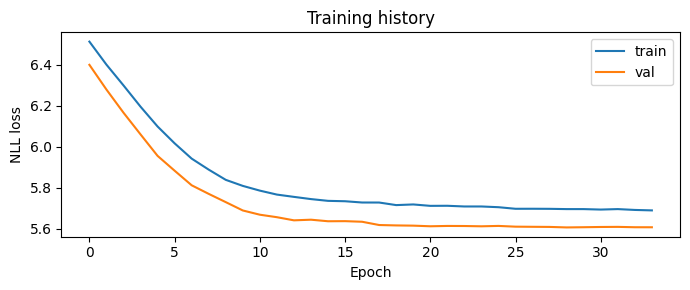

In [24]:
fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(history["train_losses"], label="train")
ax.plot(history["val_losses"],   label="val")
ax.set_xlabel("Epoch")
ax.set_ylabel("NLL loss")
ax.legend()
ax.set_title("Training history")
plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / "loss_history.png"), dpi=100)
plt.show()

# Test the model against withheld data

## Convert the NumPy rasters loaded earlier into PyTorch tensors.
Both validate_next_step_probs() and simulate_trajectory() call `get_landscape(month_index)` at each step to fetch the current environmental layers as a list of 2-D tensors.

With static (non-seasonal) rasters the month_index argument is unused. For seasonal data (e.g. monthly NDVI composites) you would index into a stack of layers here based on the current month.

In [25]:
ndvi_t  = torch.from_numpy(env_layers["ndvi"].astype(np.float32))
slope_t = torch.from_numpy(env_layers["slope"].astype(np.float32))

def get_landscape(_month_index):
    # Returns layers in the same order as LAYER_PATHS.
    return [ndvi_t, slope_t]

# Use the last 10 % of steps as the test set (matches the DataLoader split).
n_test      = int(len(step_df) * 0.1)
test_sample = step_df.iloc[-n_test:].reset_index(drop=True)
print(f"Testing on {len(test_sample):,} steps")

Testing on 1,010 steps


## `validate_next_step_probs()`
Runs the model forward on each test step and records the probability mass assigned to the *true* next location.

- **Inputs**: 
    * `model`
    * `test_sample`
        - test dataframe that contains movement steps (from the data loaded above)
     * `get_landscape`
        - retrieves the landscape layers (spatial covariates) that were used to train the model
    * `transform`
        - raster Affine transform
    * `window_size`
        - window size of the local availability window (should be the same as for training)
    * `scalar_cols`
        - scalar column names (should be set from above)
    * `yday_col`
        - which column has the yday column to ensure the correct spatial layers (if dynamic through time) are indexed
    * `month_index_fn`
        - a function mapping day-of-year → month index (used by the `get_landscape` function). Here we are using static spatial layers so we can set it to 0.

- **Outputs**: 
    * `test_sample` dataframe with three new columns appended:
        - habitat_prob   — probability at the true location from the habitat head alone
        - move_prob      — probability at the true location from the movement head alone
        - next_step_prob — joint (habitat × movement) probability at the true location

Higher values mean the model performed better (there was higher predicted probability at the observed next-step). 


In [26]:
val_results = validate_next_step_probs(
    model,
    test_sample,
    get_landscape=get_landscape,
    transform=raster_transform,
    window_size=WINDOW_SIZE,
    scalar_cols=tuple(SCALAR_COLS),
    yday_col="yday_t1",
    bearing_col="bearing_tm1",
    month_index_fn=lambda _yday: 0,   # static layers
)
print(val_results[["habitat_prob", "move_prob", "next_step_prob"]].describe())

       habitat_prob    move_prob  next_step_prob
count   1010.000000  1010.000000     1010.000000
mean       0.000193     0.026397        0.035083
std        0.000179     0.051699        0.072018
min        0.000000     0.000000        0.000000
25%        0.000092     0.000240        0.000247
50%        0.000123     0.006742        0.007731
75%        0.000189     0.029893        0.036953
max        0.000675     0.254268        0.552189


In [27]:
# Use the last 10 % of steps as the test set (matches the DataLoader split)
n_test      = int(len(step_df) * 0.1)
test_sample = step_df.iloc[-n_test:].reset_index(drop=True)
print(f"Validating on {len(test_sample):,} steps")

val_results = validate_next_step_probs(
    model,
    test_sample,
    get_landscape=get_landscape,
    transform=raster_transform,
    window_size=WINDOW_SIZE,
    scalar_cols=tuple(SCALAR_COLS),
    yday_col="yday_t1",
    bearing_col="bearing_tm1",
    month_index_fn=lambda _yday: 0,   # static layers — month doesn't matter
)
print(val_results[["habitat_prob", "move_prob", "next_step_prob"]].describe())

Validating on 1,010 steps
       habitat_prob    move_prob  next_step_prob
count   1010.000000  1010.000000     1010.000000
mean       0.000193     0.026397        0.035083
std        0.000179     0.051699        0.072018
min        0.000000     0.000000        0.000000
25%        0.000092     0.000240        0.000247
50%        0.000123     0.006742        0.007731
75%        0.000189     0.029893        0.036953
max        0.000675     0.254268        0.552189


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3))
for ax, col, title in zip(
    axes,
    ["habitat_prob", "move_prob", "next_step_prob"],
    ["Habitat", "Movement", "Next-step"],
    strict=False,
):
    data = val_results[col].dropna()
    ax.hist(data, bins=40, edgecolor="white")
    ax.set_title(title)
    ax.set_xlabel("Probability")
axes[0].set_ylabel("Count")
plt.suptitle("Next-step probability distributions (test set)", y=1.02)
plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / "validation_probs.png"), dpi=100)
plt.show()

# Simulate new data

Select starting parameters for the model.

We've set the starting location to be the first location of the observed data.

In [29]:
start_x = step_df["x1_"].iloc[0]
start_y = step_df["y1_"].iloc[0]
print(f"Starting location: ({start_x:.0f}, {start_y:.0f})")

Starting location: (41941, -1435875)


# Simulate a trajectory

## `simulate_trajectory()` 
Generates a sequence of steps by iteratively:
1. Extracting a spatial window centred on the current location.
2. Running the model to obtain a joint log-probability surface over that window.
3. Sampling the next pixel from that surface (softmax-normalised probabilities).
4. Converting the sampled pixel back to projected coordinates and advancing time.

- **Inputs**: 
    * `model`
        - the trained model
    * `get_landscape`
        - retrieves the landscape layers (spatial covariates) that were used to train the model
    * `transform`
        - raster Affine transform
    * `start_x`
        - x coordinate of starting location
    * `start_y`
        - y coordinate of starting location
    * `n_steps`
        - number of steps
    * `starting_yday`
        - starting day-of-year 
    * `starting_hour`
        - starting hour-of-day
    * `time_between_steps`
        - time between steps in hours
    * `window_size`
        - size in pixels of the local landscape
    * `month_index_fn`
        - a function mapping day-of-year → month index (used by the `get_landscape` function). Here we are using static spatial layers so we can set it to 0.

- **Outputs**: DataFrame with one row per simulated step containing:
    * `x`, `y`           
        — projected coordinates of the simulated location
    * `hour`, `yday`     
        — time variables updated at each step
    * `month_index`
        - the month index used to index the spatial variables (will be 0 if using static spatial covariates)

In [30]:
sim_df = simulate_trajectory(
    model,
    get_landscape=get_landscape,
    transform=raster_transform,
    start_x=start_x,
    start_y=start_y,
    n_steps=1000,
    starting_yday=test_sample["yday_t1"].iloc[0],
    starting_hour=test_sample["hour_t1"].iloc[0],
    time_between_steps=1.0,
    window_size=WINDOW_SIZE,
    month_index_fn=lambda _yday: 0,   # static layers
)
print(f"Simulated {len(sim_df)} steps")
sim_df.head()

Simulated 1000 steps


,x,y,hour,yday,month_index
0,41905.272779,-1.435885e+06,18.916667,255.000000,0
1,41147.764883,-1.435758e+06,19.916667,255.041667,0
2,40708.724292,-1.435091e+06,20.916667,255.083333,0
3,40889.072755,-1.434925e+06,21.916667,255.125000,0
4,40892.806893,-1.434897e+06,22.916667,255.166667,0


### Plot the simulated data

In [ ]:
fig, ax = plt.subplots(figsize=(7, 6))
rasterio.plot.show(
    env_layers["ndvi"], transform=raster_transform, ax=ax, cmap="viridis"
)
ax.plot(
    step_df["x1_"], step_df["y1_"],
    "w-o", alpha=0.5, markersize=1, linewidth=0.8, label="observed",
)
ax.plot(
    sim_df["x"], sim_df["y"],
    "r-o", markersize=1, linewidth=0.8, label="simulated",
)
ax.set_xlabel("Easting (m, projected)")
ax.set_ylabel("Northing (m, projected)")
ax.legend()
ax.set_title("Simulated vs observed buffalo locations")
plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / "simulated_trajectory.png"), dpi=100)
plt.show()